# Variational AutoEncoders.

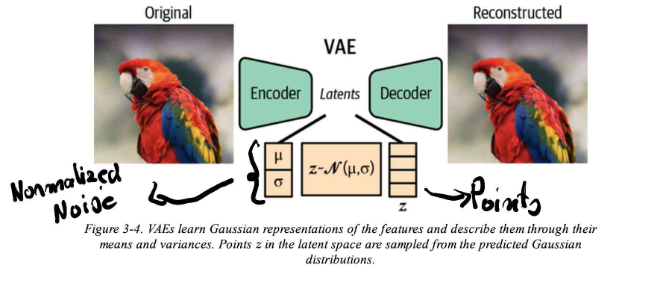

In [1]:
from typing import Tuple
import matplotlib.pyplot as plt
plt.set_cmap('gray_r')

from tinygrad.helpers import Context, trange
from tinygrad import Tensor, Device , GlobalCounters, nn, TinyJit
from tinygrad.nn.datasets import mnist

Tensor.manual_seed(42)
print(f"Default device: {Device.DEFAULT}")
X_train, Y_train, X_test, Y_test = mnist()
X_train = X_train.div(255.0)
X_test = X_test.div(255.0)

print(X_train.shape, X_train.dtype, Y_train.shape, Y_train.dtype);

Default device: AMD
(60000, 1, 28, 28) dtypes.float (60000,) dtypes.uchar


<Figure size 640x480 with 0 Axes>

In [2]:
class conv_block:
    def __init__(self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 4,
        stride: int = 2,
        padding: int = 1):
        
        
        self.conv= nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding)
        self.norm = nn.BatchNorm2d(out_channels)
    
    def __call__(self,x:Tensor) -> Tensor:
        x = self.conv(x)
        x = self.norm(x)
        return x.relu()
    
    

# New Encoder

In [3]:
class VAEEncoder:
    def __init__(self, in_channels, latent_dims: int):
        self.conv1 = conv_block(in_channels, 128)
        self.conv2 = conv_block(128,256)
        self.conv3 = conv_block(256,512)
        self.conv4 = conv_block(512,1024)

        self.mu = nn.Linear(1024, latent_dims)
        self.logvar = nn.Linear(1024,latent_dims)
    
    def __call__(self, x: Tensor) -> Tuple[Tensor,Tensor]:    # (bs, 1, 28 , 28)
        bs = x.shape[0]
        x = self.conv1(x)                       # (bs, 128, 14 ,14)
        x = self.conv2(x)                       # (bs, 256, 7 ,7)
        x = self.conv3(x)                       # (bs, 512, 3 ,3)
        x = self.conv4(x)                       # (bs, 1024, 1 ,1)
        x = x.reshape(bs, -1)                   # Reshape to (bs, 1024)
        mu = self.mu(x)
        logvar = self.logvar(x)
        return (mu, logvar)

# Decoder stays the same 
> it is just the latent space distribution that changes.

In [4]:
class conv_transpose_block:
    def __init__(self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 2,
        padding: int = 1,
        output_padding: int = 0,
        with_act: bool = True):
        self.t_conv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size,
            stride,
            padding,
            output_padding
        )
        if with_act:
            self.norm = nn.BatchNorm2d(out_channels)
 
    def __call__(self, x: Tensor) -> Tensor:
        x = self.t_conv(x)
        if hasattr(self, 'norm'):
            x = self.norm(x)
            return x.relu()
        return x

class Decoder():
    def __init__(self, out_channels: int, latent_dims:int):
        self.linear = nn.Linear(latent_dims, 1024 * 4 * 4)
        self.t_conv1 = conv_transpose_block(1024, 512)
        self.t_conv2 = conv_transpose_block(512, 256, output_padding=1)
        self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1, with_act=False)
    def __call__(self, x:Tensor) -> Tensor:
        bs = x.shape[0]
        x = self.linear(x)              #(bs, 1024 *4 *4)
        x = x.reshape((bs, 1024, 4, 4)) #(bs, 1024, 4, 4)
        x = self.t_conv1(x)             #(bs, 512, 7, 7)
        x = self.t_conv2(x)             #(bs, 256, 14, 14)
        x = self.t_conv3(x)             #(bs, out_channels, 28, 28)
        
        return x.sigmoid()              # Added sigmoid to squeeze values between (0,1)

In [5]:
class VAE():
    def __init__(self, in_channels, latent_dims):
        self.encoder = VAEEncoder(in_channels,latent_dims)
        self.decoder = Decoder(in_channels,latent_dims)
    
    def encode(self, x: Tensor) -> Tuple[Tensor,Tensor]:
        
        return self.encoder(x)
    
    def decode(self, z:Tensor) -> Tensor:
        return self.decoder(z)
    
    def sample(self, mu:Tensor, std:Tensor) -> Tensor:
        eps = Tensor.rand_like(std)
        return mu + std * eps

    def __call__(self, x: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        mu, logvar = self.encoder(x)
        std = (0.5 * logvar).exp()  # σ = exp(0.5 * log(σ²))
        z = self.sample(mu, std)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


In [ ]:
dims = 2
model = VAE(1,dims)
batch_size = 64
epochs = 10
lr = 1e-4
optim = nn.optim.AdamW(nn.state.get_parameters(model), lr=lr, eps=1e-5)

def KLDLoss(mu: Tensor, logvar: Tensor) -> Tensor:
    return -0.5 * (1 + logvar - mu.square() - logvar.exp()).sum(axis=-1)

def mse_loss(input: Tensor, target: Tensor) -> Tensor:
    return input.sub(target).square().sum(axis=-1)

# Update the loss_fn to use binary_crossentropy
def loss_fn(batch: Tensor, image: Tensor, mu: Tensor, logvar: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
    bs = batch.shape[0]
    batch_flat = batch.reshape(bs, -1)
    image_flat = image.reshape(bs, -1).clip(1e-7, 1-1e-7)
    
    # This was MSE in the book but i wanted to use BCE
    reconstruction_loss = image_flat.binary_crossentropy(batch_flat, reduction='none').sum(axis=-1)
    kl_loss = KLDLoss(mu, logvar)
    
    loss = (reconstruction_loss + kl_loss).mean(axis=0)
    return loss, reconstruction_loss.mean(), kl_loss.mean()

@Tensor.train()
@TinyJit
def train_step():
    optim.zero_grad()
    samples = Tensor.randint(batch_size, high=X_train.shape[0])
    X = X_train[samples]
    reconstructed,mu,logvar = model(X)
    loss, reconstruction_loss,kl_loss = loss_fn(X,reconstructed,mu,logvar)
    loss.backward()
    optim.step()
    return (loss.realize(), reconstruction_loss.realize(),kl_loss.realize())

In [7]:
x = Tensor.rand(32,1,28,28)
model(x)
loss_fn(x, *model(x))

(<Tensor <UOp AMD () float (<Ops.MUL: 49>, None)> on AMD with grad None>,
 <Tensor <UOp AMD () float (<Ops.MUL: 49>, None)> on AMD with grad None>,
 <Tensor <UOp AMD () float (<Ops.MUL: 49>, None)> on AMD with grad None>)

In [8]:
losses = {
    "loss": [],
    "img_loss": [],
    "kl_loss": []
}
# Calculate step_size
step_size = len(X_train) // batch_size
epochs = 10

if __name__ == "__main__":
    # Modified training loop to use trange
    with Context(BEAM=2):
        for step in (t := trange(epochs * step_size)):
            GlobalCounters.reset()
            loss, img_loss, kl_loss = train_step()
            loss_item = loss.item()
            img_loss_item = img_loss.item()
            kl_loss_item = kl_loss.item()
            
            # Append each loss to its respective list
            losses["loss"].append(loss_item)
            losses["img_loss"].append(img_loss_item)
            losses["kl_loss"].append(kl_loss_item)
            
            t.set_description(f"loss: {loss_item:6.4f}")

loss: 143.0868: 100%|███████████████████████| 9370/9370 [02:43<00:00, 57.42it/s]


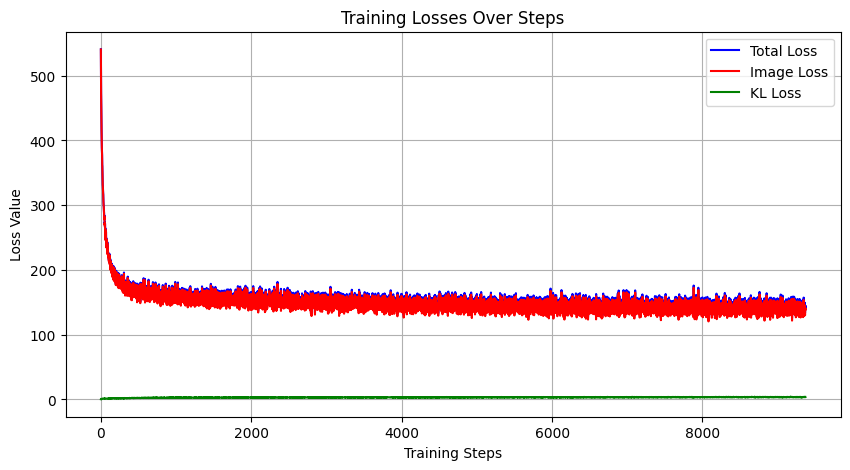

In [9]:
# --- Plotting ---
plt.figure(figsize=(10, 5))
SKIP = 0
plt.plot(losses["loss"][SKIP:], label="Total Loss", color="blue")
plt.plot(losses["img_loss"][SKIP:], label="Image Loss", color="red")
plt.plot(losses["kl_loss"][SKIP:], label="KL Loss", color="green")

plt.title("Training Losses Over Steps")
plt.xlabel("Training Steps")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True)
plt.show()


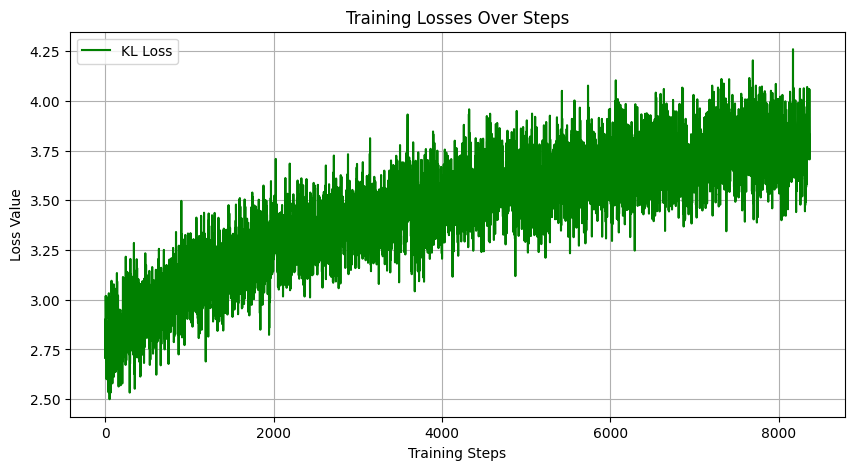

In [10]:
# --- Plotting ---
plt.figure(figsize=(10, 5))
SKIP = 1000
# plt.plot(losses["loss"][SKIP:], label="Total Loss", color="blue")
# plt.plot(losses["img_loss"][SKIP:], label="Image Loss", color="red")
plt.plot(losses["kl_loss"][SKIP:], label="KL Loss", color="green")

plt.title("Training Losses Over Steps")
plt.xlabel("Training Steps")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True)
plt.show()


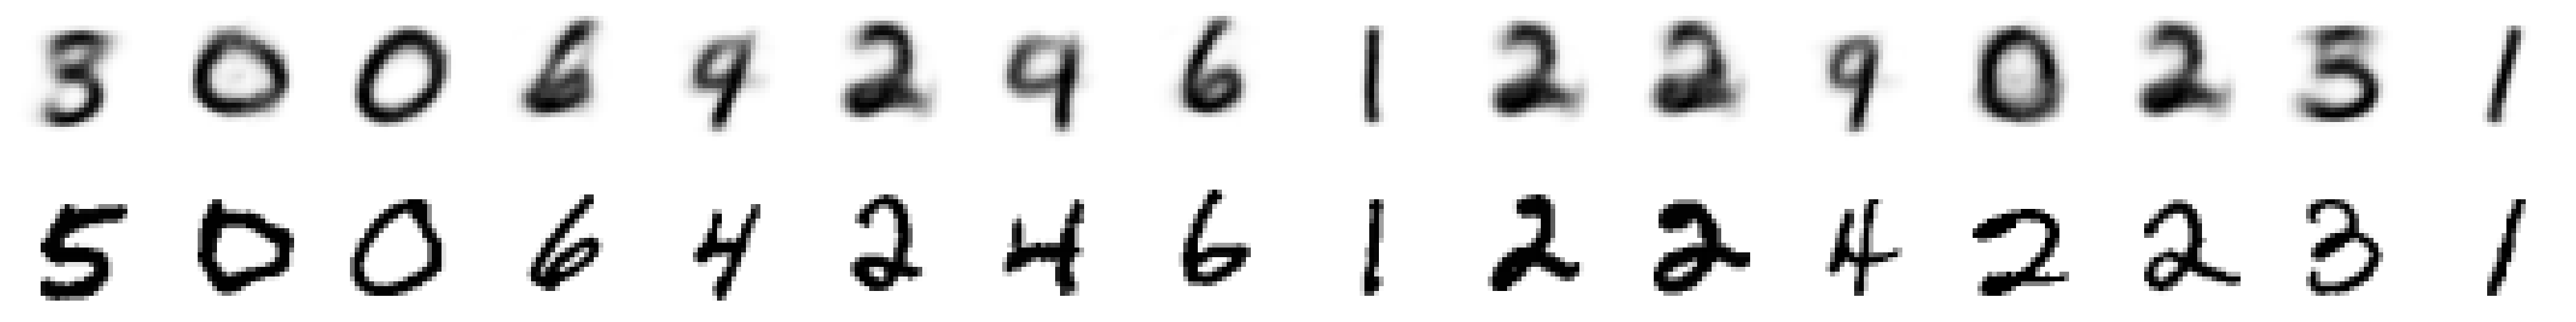

In [11]:
from afterhours_papers.helpers import show_images
# Example usage
sample_size = 16
samples = Tensor.randint(sample_size, high=X_train.shape[0])
batch = X_train[samples]

out,_,_ = model(batch)
batch_vs_preds = out.cat(batch, dim=0)

images = batch_vs_preds.reshape(sample_size*2 ,28 ,28).numpy()
# Display using the show_images function
show_images(
    images,
    nrows=2,
    ncols=sample_size,
);

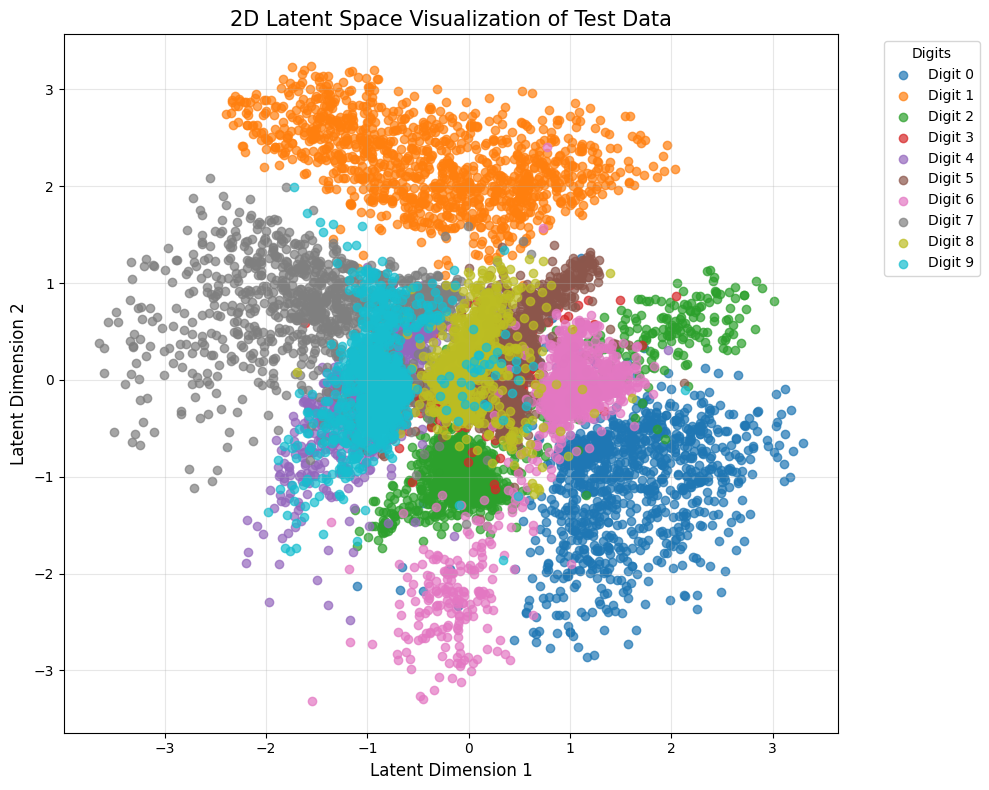

In [12]:
# Dictionary to store the encoded features and labels
encoded_data = {'x': [], 'y': [], 'label': []}

# Process X_test using tensor split functionality
batch_size = 1024
batches = X_test.split(1024)  # Split X_test into batches of 128 elements

for batch_idx, batch in enumerate(batches):
    # Calculate start index for this batch
    start_idx = batch_idx * 1024
    
    # Encode the batch using model
    mu, _  = model.encode(batch)
    
    # Store the encoded values and corresponding labels
    batch_size = batch.shape[0]  # Get actual batch size (might be smaller for the last batch)
    
    # Extract batch data efficiently
    encoded_data['x'].extend(mu[:, 0].numpy())  # First dimension as x
    encoded_data['y'].extend(mu[:, 1].numpy())  # Second dimension as y
    
    # Get the corresponding labels for this batch
    batch_labels = Y_test[start_idx:start_idx+batch_size].numpy()
    encoded_data['label'].extend(batch_labels)

# Create a DataFrame for easier plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(encoded_data)

# Create a scatter plot using matplotlib directly
plt.figure(figsize=(10, 8))

# Get unique labels and assign colors
unique_labels = np.unique(df['label'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# Plot each class with a different color
for i, label in enumerate(unique_labels):
    mask = df['label'] == label
    plt.scatter(
        df.loc[mask, 'x'], 
        df.loc[mask, 'y'],
        color=colors[i],
        label=f'Digit {int(label)}',  # Changed to show the actual digit
        alpha=0.7,
        # s=50  # Point size
    )

# Add a title and labels
plt.title('2D Latent Space Visualization of Test Data', fontsize=15)
plt.xlabel('Latent Dimension 1', fontsize=12)
plt.ylabel('Latent Dimension 2', fontsize=12)

# Add a legend
plt.legend(title='Digits', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve the plot appearance
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Now we should be able to sample random data from the distribution and, hopefully obrain images that resemble our input dataset.

In [13]:
sample_size = 16
z = Tensor.normal(sample_size,dims)
out= model.decode(z)
out.shape


(16, 1, 28, 28)

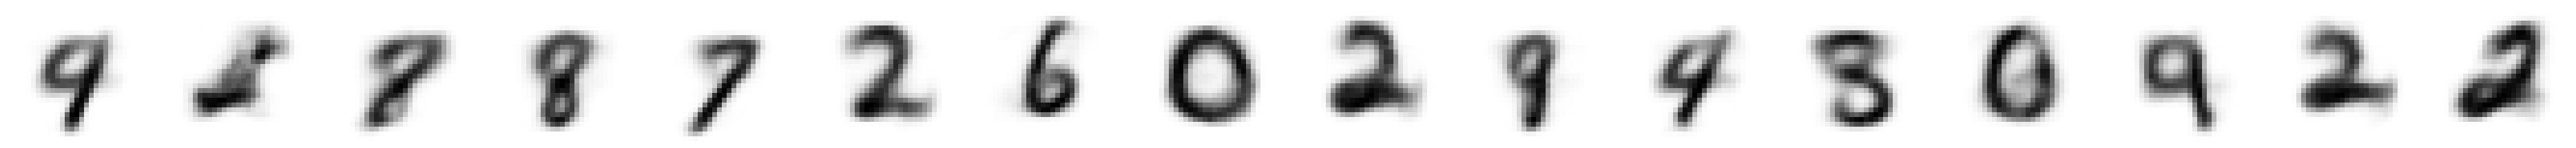

In [14]:
images = out.reshape(sample_size ,28 ,28).numpy()
# Display using the show_images function
show_images(
    images,
    nrows=1,
);

In [15]:
inputs = []
for x in np.linspace(-2, 2, 20):
    for y in np.linspace(-2, 2, 20):
        extended_input = [x, y]
        inputs.append(extended_input)
z = Tensor(inputs)
z.shape


(400, 2)

In [16]:
decoded = model.decode(z)
decoded = decoded.reshape(400,28,28)


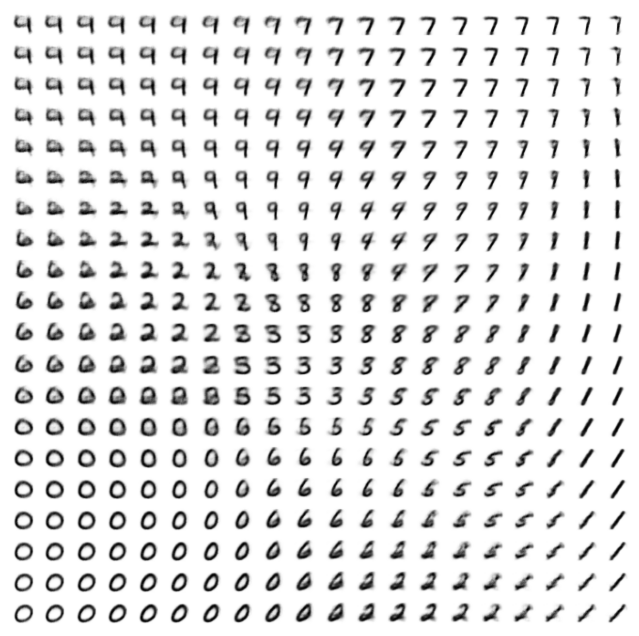

In [17]:
show_images(decoded.numpy(), imsize=0.4, nrows=20)